# Probabilistic model Eval 2

Taking a card from the discard pile tells the opponent the card is
useful to you, so they can defend its melds. `gamma` prices that leak: the draw
rule takes the discard iff `V_take + gamma * info_leak < V_stock`.

Only a belief-using opponent can punish the leak, our single valid test is prob-vs-prob self-play.

The leak must be priced by what the card reveals, not its points.
The first version used `gamma * card_value`.
It is now `gamma * info_leak`, where `info_leak` counts the meld partners
of the taken card we already hold — 0 for an isolated grab, high
for a card we are visibly building around.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agent.eval.harness import run_match, sweep

# Self-play is 2x belief cost (both sides Monte-Carlo their knock EV), so keep
# these modest; n_jobs parallelises across the gamma cells.
N_GAMES       = 20
KNOCK_SAMPLES = 64
BASE_SEED     = 0
N_JOBS        = -1
ALPHA, KAPPA  = 0.1, 0.0          # fixed at the chosen baseline params

pd.set_option("display.float_format", lambda v: f"{v:.3f}")

from math import erfc, sqrt as _sqrt
def add_significance(df, n_games, baseline=0.5):
    """Win-rate SE + two-sided z-test vs `baseline` (0.5 = even with the self-copy)."""
    out = df.copy()
    p = out["win_rate"].to_numpy()
    se = np.sqrt(p * (1 - p) / n_games)
    z = np.divide(p - baseline, se, out=np.zeros_like(p), where=se > 0)
    out["se"] = se
    out["z_vs_0.5"] = z
    out["p_value"] = [erfc(abs(zi) / _sqrt(2)) for zi in z]
    return out

## Coarse sweep

Subject = probabilistic with varying `gamma`; opponent = an identical agent
pinned at `gamma=0`. Seats alternate to cancel first-move advantage.

In [3]:
OPP = ("probabilistic", {"gamma": 0.0, "alpha": ALPHA, "kappa": KAPPA,
                         "knock_samples": KNOCK_SAMPLES})
gamma_grid = sweep(
    {"gamma": [0.0, 0.5, 1.0, 2.0, 4.0]},
    subject_kind="probabilistic",
    opponent=OPP,
    fixed={"alpha": ALPHA, "kappa": KAPPA, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,
)
df_gamma = add_significance(pd.DataFrame(gamma_grid), N_GAMES)
df_gamma.sort_values("win_rate", ascending=False)[
    ["gamma", "win_rate", "se", "z_vs_0.5", "p_value", "avg_score_margin"]]

,gamma,win_rate,se,z_vs_0.5,p_value,avg_score_margin
0,0.000,0.750,0.097,2.582,0.010,6.600
1,0.500,0.750,0.097,2.582,0.010,6.500
2,1.000,0.700,0.102,1.952,0.051,5.700
3,2.000,0.600,0.110,0.913,0.361,3.250
4,4.000,0.550,0.111,0.449,0.653,2.800


In [ ]:
# win_rate vs gamma with +/-1 SE bars; dashed line = parity with the gamma=0 self-copy.
d = df_gamma.sort_values("gamma")
plt.figure(figsize=(6, 4))
plt.errorbar(d["gamma"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(0.5, ls="--", color="grey")
plt.xlabel("gamma (info-leak penalty)"); plt.ylabel("win_rate vs gamma=0 self-copy")
plt.title(f"Gamma self-play  (n={N_GAMES}/cell, +/-1 SE)")
plt.tight_layout(); plt.show()

## Fine sweep near gamma=0

Finer grid at higher n, read against the `gamma=0` control. We are hunting for any
gamma whose bar sits **above** the control line — that would mean defending the
leak beats not defending it. (Heavy cell; lower `N_GAMES_FINE` / `KNOCK_SAMPLES`
if slow.)

In [4]:
N_GAMES_FINE = 200

# Control: gamma=0 self-play. With CRN this is the reference the fine grid is read
# against; it should drift toward 0.5 as N grows.
ctrl = run_match(("probabilistic", {"gamma": 0.0, "alpha": ALPHA, "kappa": KAPPA,
                                     "knock_samples": KNOCK_SAMPLES}),
                 OPP, n_games=N_GAMES_FINE, base_seed=BASE_SEED, alternate_seats=True)
print(f"gamma=0 control: win={ctrl['win_rate']:.3f}  (want ~0.5 -- if far off, n is still too small)")

gamma=0 control: win=0.530  (want ~0.5 -- if far off, n is still too small)


In [5]:
gamma_fine = sweep(
    {"gamma": [0.1, 0.2, 0.3, 0.4, 0.5, 0.75]},
    subject_kind="probabilistic",
    opponent=OPP,
    fixed={"alpha": ALPHA, "kappa": KAPPA, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES_FINE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,
)
df_fine = add_significance(pd.DataFrame(gamma_fine), N_GAMES_FINE)
df_fine.sort_values("win_rate", ascending=False)[
    ["gamma", "win_rate", "se", "z_vs_0.5", "p_value", "avg_score_margin"]]

,gamma,win_rate,se,z_vs_0.5,p_value,avg_score_margin
2,0.300,0.530,0.035,0.850,0.395,1.060
5,0.750,0.530,0.035,0.850,0.395,0.745
1,0.200,0.525,0.035,0.708,0.479,0.885
3,0.400,0.525,0.035,0.708,0.479,0.825
4,0.500,0.525,0.035,0.708,0.479,0.770
0,0.100,0.520,0.035,0.566,0.571,0.725


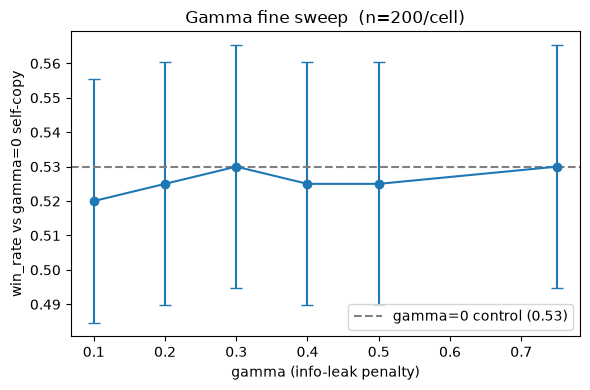

In [7]:
# Read vs the gamma=0 control (dashed): a point ABOVE it means that gamma beats
# no-penalty on the same deals. Flat/below => the info-leak penalty doesn't pay.
d = df_fine.sort_values("gamma")
ctrl_win = float(ctrl['win_rate'])
plt.figure(figsize=(6, 4))
plt.errorbar(d["gamma"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(ctrl_win, ls="--", color="grey", label=f"gamma=0 control ({ctrl_win:.2f})")
plt.xlabel("gamma (info-leak penalty)"); plt.ylabel("win_rate vs gamma=0 self-copy")
plt.title(f"Gamma fine sweep  (n={N_GAMES_FINE}/cell)"); plt.legend()
plt.tight_layout(); plt.show()

## Conclusion

At n=200 the curve is flat on the `gamma=0` control (~0.53).

Even in self-play — the most exploitable case for an info leak — defending the
leak is not worth the card you forgo.

**Keep `gamma = 0`**, now confirmed by evidence rather than assumed. This completes
the knob picture — alpha opponent-dependent, kappa inert-then-harmful, gamma a
no-op — and points the same way as Eval 1: the ceiling is the one-ply policy, not
the parameters.